## Лабораторная работа 2

## “Рекомендательные системы”

Был выбран датасет для https://www.recsyschallenge.com/2025/ в котором представлен набор данных о действиях пользователей в каком-то онлайн-магазине. Соответственно для рекомендательной системы будем использовать эти данные, чтобы научиться рекомендовать релевантный товар

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
!pip install pyarrow
!pip install fastparquet


[notice] A new release of pip available: 22.3.1 -> 25.2
[notice] To update, run: C:\Python311\python.exe -m pip install --upgrade pip



[notice] A new release of pip available: 22.3.1 -> 25.2
[notice] To update, run: C:\Python311\python.exe -m pip install --upgrade pip


In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("pastel")

# Путь к данным
DATA_PATH = "challenge_dataset/input"

# Проверим, что всё на месте
os.listdir(DATA_PATH)

['add_to_cart.parquet',
 'page_visit.parquet',
 'product_buy.parquet',
 'relevant_clients.npy',
 'remove_from_cart.parquet',
 'search_query.parquet']

### Структура данных

Датасет состоит из следующих файлов:
- `add_to_cart.parquet` — события добавления товаров в корзину
- `remove_from_cart.parquet` — удаление из корзины
- `product_buy.parquet` — покупки товаров
- `page_visit.parquet` — просмотры страниц товаров
- `search_query.parquet` — поисковые запросы


In [4]:
files = {
    "add_to_cart": pd.read_parquet(f"{DATA_PATH}/add_to_cart.parquet"),
    "remove_from_cart": pd.read_parquet(f"{DATA_PATH}/remove_from_cart.parquet"),
    "product_buy": pd.read_parquet(f"{DATA_PATH}/product_buy.parquet"),
    "page_visit": pd.read_parquet(f"{DATA_PATH}/page_visit.parquet"),
    "search_query": pd.read_parquet(f"{DATA_PATH}/search_query.parquet"),
}

clients = np.load(f"{DATA_PATH}/relevant_clients.npy")


# EDA

Для начала просто посмотрим на формат и наполнение файлов

In [5]:
for name, df in files.items():
    print(f"\n=== {name.upper()} ===")
    display(df.head(3))
    print(df.dtypes)


=== ADD_TO_CART ===


,client_id,timestamp,sku
0,19433713,2022-06-23 00:10:20,649662
1,15811394,2022-06-23 00:11:20,615072
2,3465674,2022-06-23 00:12:20,1137565


client_id             int64
timestamp    datetime64[ns]
sku                   int64
dtype: object

=== REMOVE_FROM_CART ===


,client_id,timestamp,sku
0,16013543,2022-06-23 00:12:25,148228
1,6411180,2022-06-23 00:15:50,1321311
2,6411180,2022-06-23 00:15:55,161900


client_id             int64
timestamp    datetime64[ns]
sku                   int64
dtype: object

=== PRODUCT_BUY ===


...

client_id             int64
timestamp    datetime64[ns]
sku                   int64
dtype: object

=== PAGE_VISIT ===


,client_id,timestamp,url
0,13083737,2022-06-23 00:10:00,7168398
1,14823465,2022-06-23 00:10:00,12455356
2,22003566,2022-06-23 00:10:00,16107006


client_id             int64
timestamp    datetime64[ns]
url                   int64
dtype: object

=== SEARCH_QUERY ===


,client_id,timestamp,query
0,12965754,2022-06-23 00:10:00,[202 151 206 232 232 181 181 55 9 57 236 ...
1,12965754,2022-06-23 00:10:05,[202 151 206 232 232 181 181 55 9 57 236 ...
2,14797776,2022-06-23 00:10:05,[168 151 190 159 215 117 50 9 147 168 94 2...


client_id             int64
timestamp    datetime64[ns]
query                object
dtype: object


In [6]:
# ================================================================
# 1. Общая статистика
# ================================================================

stats = []
for name, df in files.items():
    users = df["client_id"].nunique()
    items = np.bitwise_or.reduce([df[col_name].nunique() if col_name in df.columns else 0 for col_name in ["sku", "url", "query"]])
    stats.append({
        "event_type": name,
        "rows": len(df),
        "unique_users": users,
        "unique_items": items,
    })

all_users = set()
for df in files.values():
    all_users.update(df["client_id"].unique())
print("Total unique users:", len(all_users))

pd.DataFrame(stats)


Total unique users: 18688704


,event_type,rows,unique_users,unique_items
0,add_to_cart,5674064,1887989,1178412
1,remove_from_cart,1937170,552932,650078
2,product_buy,1775394,744980,519606
3,page_visit,156032014,18435078,12650786
4,search_query,10218831,1288493,2472873


Количество событий действительно совпадает с тем, что было указано на https://www.recsyschallenge.com/2025/

Количество уникальных пользователей и товаров меньше, чем общее количество строк (что логично), так как это значит что, либо разные пользователи взаимодействуют с одним товаром, либо наоборот один пользователь взаимодействует с разными товарами

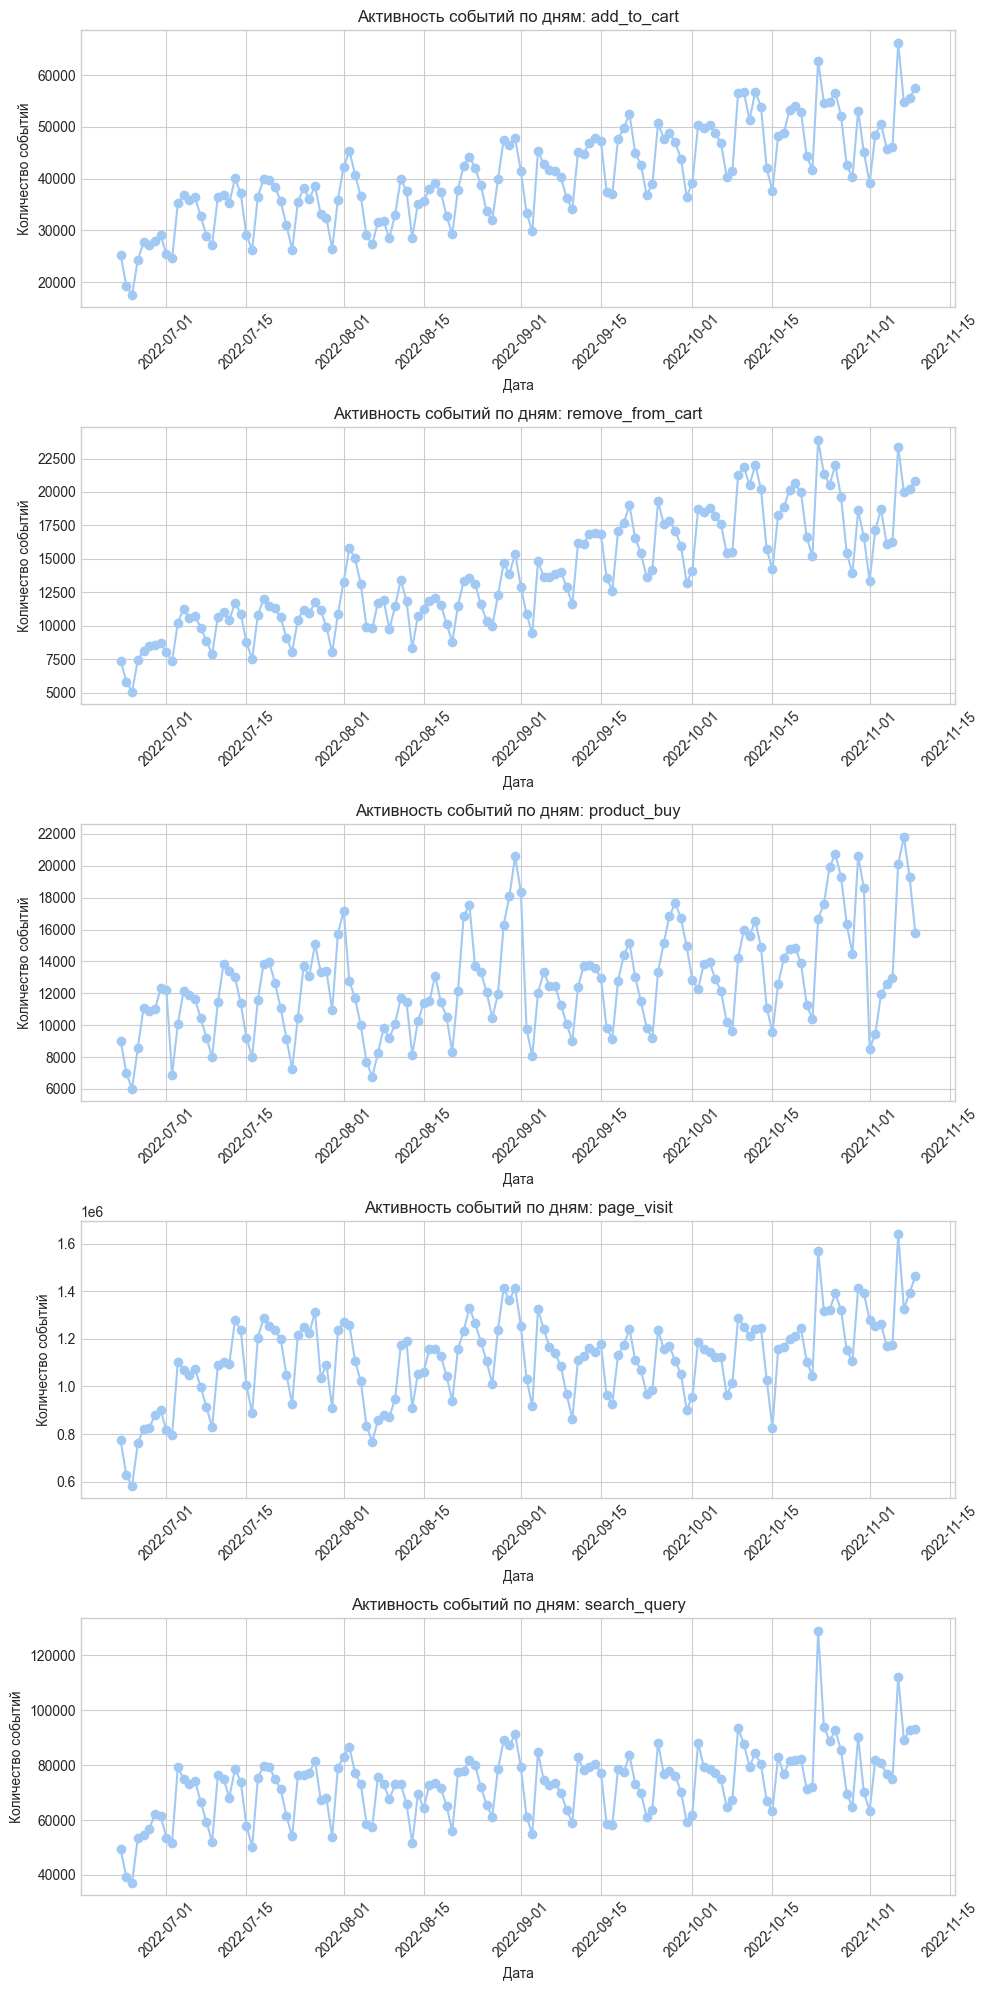

In [7]:
# ================================================================
# 2. Временная динамика активности
# ================================================================

fig, axes = plt.subplots(len(files), 1, figsize=(10, 4 * len(files)))

for ax, (name, df) in zip(axes, files.items()):
    df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
    df = df.dropna(subset=["timestamp"])

    daily = df.groupby(df["timestamp"].dt.date).size()

    ax.plot(daily.index, daily.values, marker="o", linewidth=1.5)
    ax.set_title(f"Активность событий по дням: {name}")
    ax.set_xlabel("Дата")
    ax.set_ylabel("Количество событий")
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


В целом прослеживается положительный тренд, количество событий (каждого типа) постепенно увеличивается. Также на графиках можно видеть пики по количеству событий, которые скорее всего связаны с выходными/праздничными днями

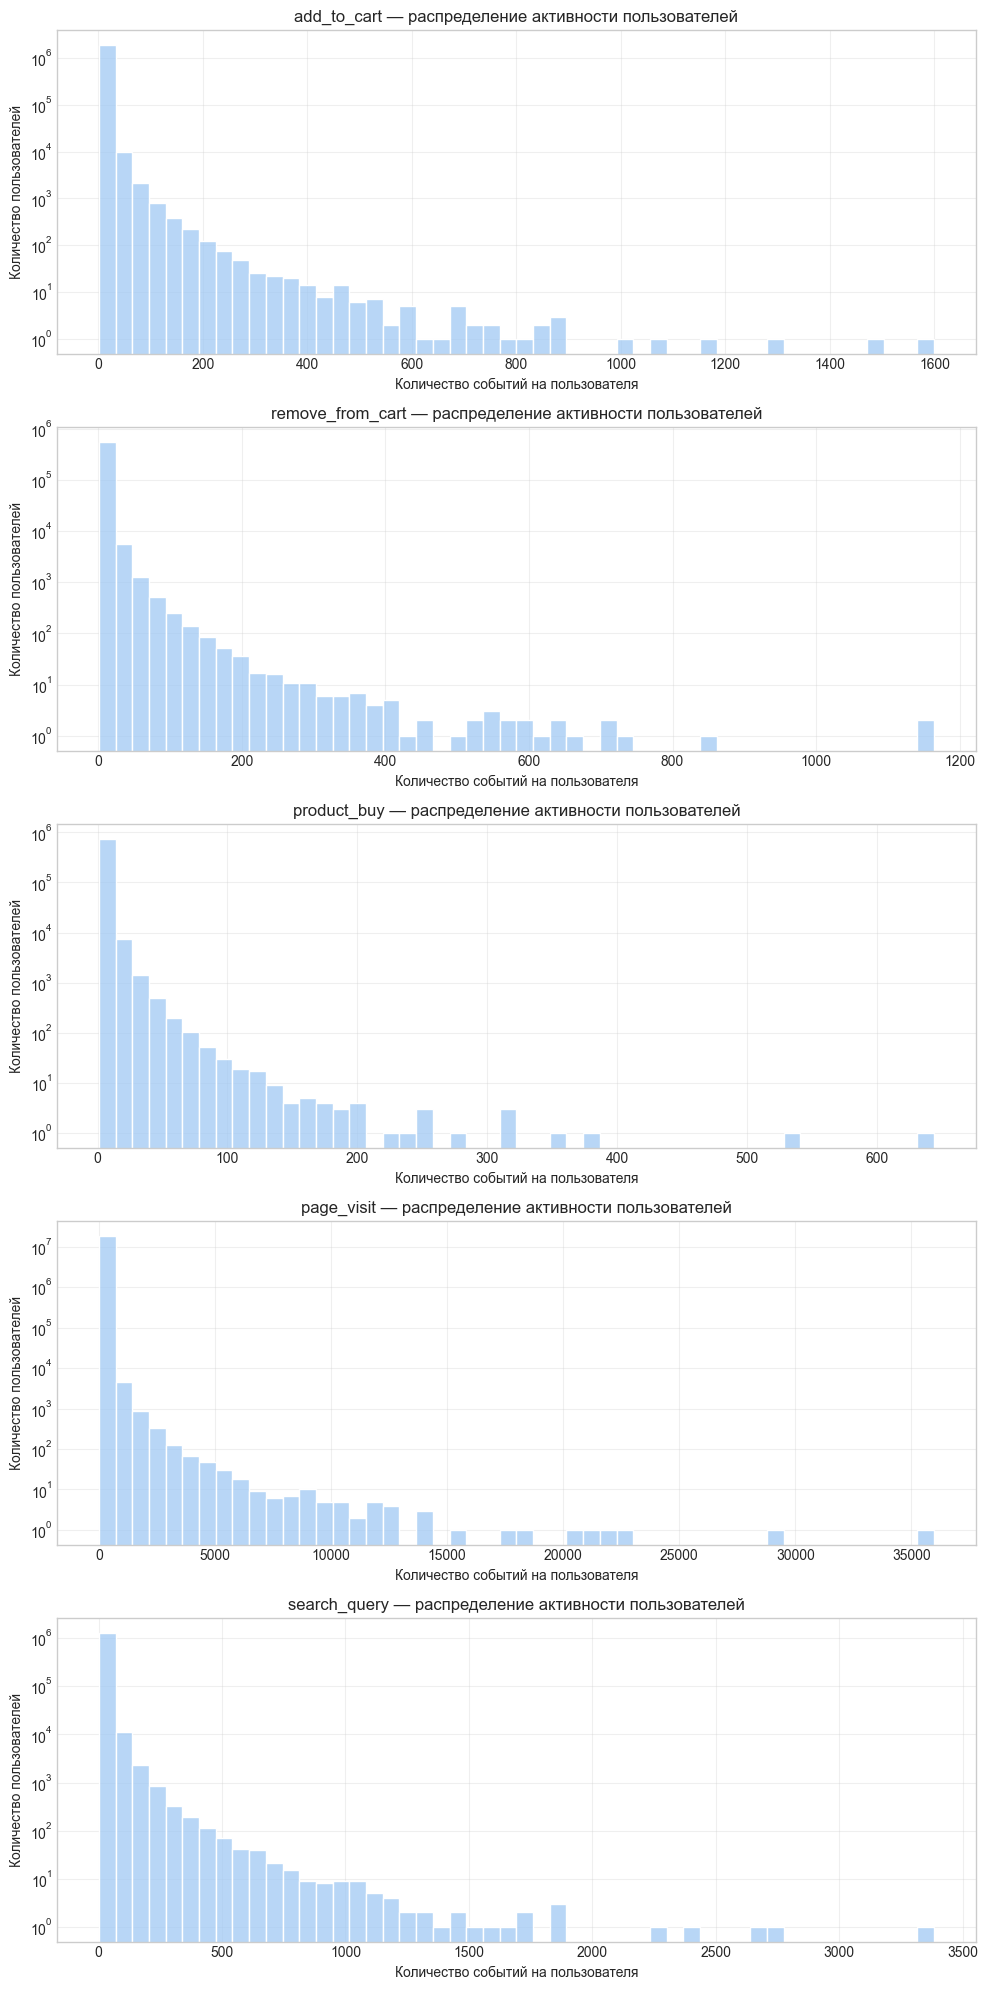

In [8]:
# ================================================================
# 3. Активность пользователей
# ================================================================

user_activity = {
    name: df["client_id"].value_counts()
    for name, df in files.items() if "client_id" in df.columns
}

fig, axes = plt.subplots(len(files), 1, figsize=(10, 4 * len(files)))
axes = axes.flatten()

for i, (name, counts) in enumerate(user_activity.items()):
    sns.histplot(counts.values, bins=50, ax=axes[i])
    axes[i].set_title(f"{name} — распределение активности пользователей")
    axes[i].set_xlabel("Количество событий на пользователя")
    axes[i].set_ylabel("Количество пользователей")
    axes[i].set_yscale('log')
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()


Смотрим на активность пользователей по каждому типу событий. Пришлось выбрать логарифмическую шкалу по оси Y, так как оказалось огромное количество пользователей, которые делали небольшое количество действий (Например 100_000 пользователей купило не больше 12 товаров. Но при этом есть несколько пользователей, которые купили более 1500 товаров)

Хотя некоторые значение выглядят как выбросы - например более 30000 посещений страниц товаров кажется слишком большим числом для человека. Данные представлены за 5 месяцев (около 150 дней), а значит это 30000 / 150 = 200 просмотров товаров в день. Много, но все еще реалистично

In [9]:
# ================================================================
# 4. Проверка качества данных
# ================================================================

for name, df in files.items():
    print()
    print(f"=== {name.upper()} ===")
    print("Пропуски:")
    print(df.isnull().mean())

    dup_count = df.duplicated().sum()
    print(f"Дубликатов: {dup_count}")
    print(f"Доля дублей: {dup_count/len(df)}")



=== ADD_TO_CART ===
Пропуски:
client_id    0.0
timestamp    0.0
sku          0.0
dtype: float64
Дубликатов: 107117
Доля дублей: 0.018878355972015825

=== REMOVE_FROM_CART ===
Пропуски:
client_id    0.0
timestamp    0.0
sku          0.0
dtype: float64
Дубликатов: 104293
Доля дублей: 0.053837814956870074

=== PRODUCT_BUY ===
Пропуски:
client_id    0.0
timestamp    0.0
sku          0.0
dtype: float64
Дубликатов: 283545
Доля дублей: 0.15970821124775683

=== PAGE_VISIT ===
Пропуски:
client_id    0.0
timestamp    0.0
url          0.0
dtype: float64
Дубликатов: 15981402
Доля дублей: 0.1024238653998275

=== SEARCH_QUERY ===
Пропуски:
client_id    0.0
timestamp    0.0
query        0.0
dtype: float64
Дубликатов: 576286
Доля дублей: 0.05639451322758934


Пустых значений нет, но при этом есть дубликаты строк.

In [10]:
# ================================================================
# 5. Удаление дублей
# ================================================================

for name, df in files.items():
    if "client_id" in df.columns and "sku" in df.columns:
        dup_count_pairs = df.duplicated(subset=["client_id", "sku"]).sum()
        print(f"Дубликатов (client_id, sku): {dup_count_pairs}")

        before = len(df)
        df = df.drop_duplicates(subset=["client_id", "sku"])
        after = len(df)
        if before != after:
            print(f"Удалено {before - after} дублей по (client_id, sku) из {name}")
            files[name] = df


Дубликатов (client_id, sku): 1295292
Удалено 1295292 дублей по (client_id, sku) из add_to_cart
Дубликатов (client_id, sku): 400367
Удалено 400367 дублей по (client_id, sku) из remove_from_cart
Дубликатов (client_id, sku): 378641
Удалено 378641 дублей по (client_id, sku) из product_buy


Далее посмотрим на свойства товаров, которые представлены в датасете

In [11]:
product_props = pd.read_parquet("challenge_dataset/product_properties.parquet")
product_props.head()

,sku,category,price,name
0,101733,6552,13,[131 245 189 142 164 164 138 254 91 83 80 1...
1,184680,6153,59,[219 48 162 96 67 72 96 44 12 250 7 2...
2,540546,618,99,[ 56 212 52 212 212 212 212 19 212 212 212 1...
3,1601877,4378,62,[164 192 102 16 237 106 83 164 53 14 193 1...
4,1022239,5158,48,[167 191 141 57 130 76 45 89 136 129 57 1...


In [12]:
import numpy as np
import pandas as pd

# Загружаем данные
product_props = pd.read_parquet("challenge_dataset/product_properties.parquet")
product_buy = pd.read_parquet("challenge_dataset/input/product_buy.parquet")

# Загружаем целевые категории
propensity_categories = np.load("challenge_dataset/target/propensity_category.npy")

# Фильтрация по целевым категориям
filtered_products = product_props[product_props["category"].isin(propensity_categories)]
filtered_buys = product_buy[product_buy["sku"].isin(filtered_products["sku"])]

print(f"Всего товаров: {len(product_props):,}")
print(f"Товаров в целевых категориях: {len(filtered_products):,}")
print(f"Событий покупок в целевых категориях: {len(filtered_buys):,}")
print(f"Уникальных пользователей (в этих категориях): {filtered_buys['client_id'].nunique():,}")


Всего товаров: 1,260,365
Товаров в целевых категориях: 355,725
Событий покупок в целевых категориях: 636,781
Уникальных пользователей (в этих категориях): 315,880


In [13]:
print("количество уникальных товаров в каждой категории")

unique_items_per_cat = (
    filtered_products.groupby("category")["sku"]
    .nunique()
    .reset_index(name="unique_items")
    .sort_values("unique_items", ascending=False)
    .reset_index(drop=True)
)

display(unique_items_per_cat.head(10))


количество уникальных товаров в каждой категории


,category,unique_items
0,258,42316
1,949,11288
2,1096,10897
3,1135,7650
4,2890,7517
5,2964,7046
6,2698,7006
7,1732,6458
8,1429,6386
9,3138,6373


In [14]:
print("количество событий покупок в каждой категории")

events_per_cat = (
    filtered_buys
    .merge(filtered_products[["sku", "category"]], on="sku", how="left")
    .groupby("category")
    .size()
    .reset_index(name="num_events")
    .sort_values("num_events", ascending=False)
    .reset_index(drop=True)
)

display(events_per_cat.head(10))


количество событий покупок в каждой категории


,category,num_events
0,258,41211
1,1096,28019
2,1966,26464
3,4092,21285
4,6356,15143
5,3138,14986
6,2964,14781
7,791,14766
8,4444,11440
9,1429,9411


In [15]:
print("количество уникальных пользователей в каждой категории")

unique_users_per_cat = (
    filtered_buys
    .merge(filtered_products[["sku", "category"]], on="sku", how="left")
    .groupby("category")["client_id"]
    .nunique()
    .reset_index(name="unique_users")
    .sort_values("unique_users", ascending=False)
    .reset_index(drop=True)
)

display(unique_users_per_cat.head(10))


количество уникальных пользователей в каждой категории


,category,unique_users
0,258,28043
1,4092,16019
2,1096,11512
3,791,9388
4,6356,9121
5,2964,9113
6,3138,8874
7,4444,8396
8,1429,6720
9,37,6146


# Методы формирования рекомендации

В качестве рекомендации будем рассматривать предложения о покупке какого-либо товара. Информация о покупках содержится в файле /challenge_dataset/input/product_buy.parquet. Так как в датасете очень большое количество товаров, было принято решение ограничиться лишь частью категорий товаров

In [16]:
import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix

# ================================================================
# 1. Загрузка категорий и свойств товаров
# ================================================================
# propensity_categories = np.load("challenge_dataset/target/propensity_category.npy")[80:]
propensity_categories = unique_users_per_cat["category"][-30:]

product_props = pd.read_parquet("challenge_dataset/product_properties.parquet")
df_buy = files["product_buy"]

print("Количество категорий:", len(propensity_categories))

# ================================================================
# 2. Фильтрация по целевым категориям
# ================================================================
filtered_products = product_props[product_props["category"].isin(propensity_categories)]
target_skus = set(filtered_products["sku"].values)
df_buy = df_buy[df_buy["sku"].isin(target_skus)]

print("Товаров в целевых категориях:", len(target_skus))
print("Количество событий покупок после фильтрации:", len(df_buy))
print("Количество уникальных пользователей:", df_buy["client_id"].nunique())
print("Количество уникальных товаров:", df_buy["sku"].nunique())

# ================================================================
# 3. Определяем последнюю дату и делаем временное разбиение для train и test
# ================================================================
df_buy["timestamp"] = pd.to_datetime(df_buy["timestamp"])
df_buy["month"] = df_buy["timestamp"].dt.to_period("M")

last_month = df_buy["month"].max()
print(f"Последний месяц в данных: {last_month}")

df_train = df_buy[df_buy["month"] < last_month]
df_test  = df_buy[df_buy["month"] == last_month]

print(f"Событий в train: {len(df_train)}, в test: {len(df_test)}")

# ================================================================
# 4. Строим общее пространство пользователей и товаров
# ================================================================
all_users = np.sort(df_buy["client_id"].unique())
all_items = np.sort(df_buy["sku"].unique())

user_to_idx = {u: i for i, u in enumerate(all_users)}
item_to_idx = {it: i for i, it in enumerate(all_items)}

idx_to_user = {v: k for k, v in user_to_idx.items()}
idx_to_item = {v: k for k, v in item_to_idx.items()}

def build_matrix(df, user_to_idx, item_to_idx, shape):
    rows = df["client_id"].map(user_to_idx)
    cols = df["sku"].map(item_to_idx)
    data = np.ones(len(df), dtype=np.float32)
    return csr_matrix((data, (rows, cols)), shape=shape, dtype=np.float32)

shape = (len(all_users), len(all_items))
train_matrix = build_matrix(df_train, user_to_idx, item_to_idx, shape)
test_matrix  = build_matrix(df_test,  user_to_idx, item_to_idx, shape)

print(f"Матрица train: {train_matrix.shape}, test: {test_matrix.shape}")

# Проверим пересечение пользователей и товаров
print("Совпадающие пользователи:", np.isin(df_test["client_id"].unique(), df_train["client_id"].unique()).mean())
print("Совпадающие товары:", np.isin(df_test["sku"].unique(), df_train["sku"].unique()).mean())


Количество категорий: 30
Товаров в целевых категориях: 58547
Количество событий покупок после фильтрации: 82609
Количество уникальных пользователей: 59168
Количество уникальных товаров: 25734
Последний месяц в данных: 2022-11
Событий в train: 77768, в test: 4841
Матрица train: (59168, 25734), test: (59168, 25734)
Совпадающие пользователи: 0.13041314086610253
Совпадающие товары: 0.5483754512635379


In [17]:
# Функция для отображения информации по индексу товара. Используется для наглядного отображения результатов моделей
def show_recommended_info(recommended_skus):
    recommended_info = (
        product_props[product_props["sku"].isin(recommended_skus)]
        .drop_duplicates("sku")
        .reset_index(drop=True)
    )

    recommended_info["order"] = recommended_info["sku"].apply(lambda x: recommended_skus.index(x))
    recommended_info = recommended_info.sort_values("order").drop(columns="order").reset_index(drop=True)
    
    display(recommended_info)

## MostPop

Самый примитивный метод: просто посчитаем самые покупаемые товары и будем их рекомендовать.

Такой метод не учитывает индивидуальность конкретного пользователя, но в целом его удобно применять, например, когда пользователь совсем новый.


In [29]:
class MostPop:
    def __init__(self):
        self.popularity = None
        self.top_items = None

    def fit(self, X):
        self.popularity = np.array(X.sum(axis=0)).ravel()
        self.top_items = np.argsort(-self.popularity)
        return self

    def recommend(self, _ = None, N=10):
        return self.top_items[:N]

mostpop = MostPop().fit(train_matrix)
recommended_items = mostpop.recommend(N=10)
recommended_skus = [idx_to_item[i] for i in recommended_items]

print("Топ-10 популярных товаров:", recommended_skus)

show_recommended_info(recommended_skus)


Топ-10 популярных товаров: [np.int64(867128), np.int64(393893), np.int64(832892), np.int64(724841), np.int64(337267), np.int64(534158), np.int64(847893), np.int64(149543), np.int64(12727), np.int64(541003)]


,sku,category,price,name
0,867128,2096,61,[ 85 228 242 160 48 121 227 28 57 129 228 ...
1,393893,1665,41,[111 69 10 52 69 75 135 106 69 146 183 2...
2,832892,2096,64,[ 38 215 55 149 48 121 50 28 109 48 195 2...
3,724841,4448,15,[ 82 118 118 79 141 118 118 118 7 118 160 1...
4,337267,608,88,[122 31 102 71 16 33 81 254 114 105 41 2...
5,534158,6119,72,[104 177 90 90 29 173 7 29 96 58 143 ...
6,847893,4683,46,[ 13 33 24 152 213 165 169 98 214 172 88 2...
7,149543,3587,17,[ 82 118 118 79 141 118 118 118 7 118 67 1...
8,12727,1665,25,[111 58 10 52 0 82 135 106 69 231 255 ...
9,541003,3587,19,[ 82 118 118 79 141 118 118 118 7 118 67 1...


## ItemKNN

Находим похожие товары по косинусному сходству их взаимодействий с пользователями. То есть для каждого пользователя будут рекомендоваться товары, которые схожы с теми, что пользователь уже брал.

Так как мы можем выделить явные взаимодействия пользователей и товаров (в данном случае это покупка товара), то этот метод позволит учитывать эти взаимодействия для выдачи рекомендаций


In [19]:
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import csr_matrix

class ItemKNN:
    def __init__(self):
        self.similarity = None

    def fit(self, X):
        # X — csr_matrix (user * item)
        sim = cosine_similarity(X.T, dense_output=True)
        np.fill_diagonal(sim, 0)
        self.similarity = sim
        return self

    def recommend(self, user_vector, N=10):
        # user_vector - 1 * items
        scores = user_vector @ self.similarity
        scores = np.array(scores).ravel()

        # Убираем уже купленные товары
        bought_idx = user_vector.nonzero()[1]
        scores[bought_idx] = -np.inf

        # Топ-N рекомендаций
        top_items = np.argsort(-scores)[:N]
        return top_items


itemknn = ItemKNN().fit(train_matrix)


In [20]:
user_idx = 0
user_vector = train_matrix[user_idx]
recommended_items = itemknn.recommend(user_vector, N=10)
recommended_skus = [idx_to_item[i] for i in recommended_items]
print("ItemKNN рекомендации:", recommended_skus)

show_recommended_info(recommended_skus)


ItemKNN рекомендации: [np.int64(521948), np.int64(90891), np.int64(1338402), np.int64(897447), np.int64(1277698), np.int64(414209), np.int64(1621785), np.int64(1621796), np.int64(1621799), np.int64(1621816)]


,sku,category,price,name
0,521948,2914,20,[130 48 31 216 191 53 109 35 102 207 122 ...
1,90891,2914,34,[205 14 64 34 154 56 216 157 205 56 42 ...
2,1338402,2914,32,[255 206 109 56 56 64 56 157 205 56 206 ...
3,897447,2914,32,[255 206 64 34 56 64 56 157 205 56 206 ...
4,1277698,2914,31,[255 206 109 34 56 206 56 157 205 56 206 ...
5,414209,2914,32,[255 206 109 34 56 206 56 157 205 56 206 ...
6,1621785,3825,0,[212 40 194 18 213 77 22 238 18 147 106 1...
7,1621796,2914,35,[255 206 195 64 124 64 167 157 205 56 64 1...
8,1621799,735,66,[ 58 221 38 232 76 76 161 2 34 76 221 1...
9,1621816,2914,6,[255 14 122 34 56 206 46 157 205 56 206 1...


## EASE

Линейная модель, которая не требует обучения по эпохам. Строит матрицу весов, которая показывает как товары связаны между собой. А регуляризация позволяет бороться с переобучением на самые популярные товары.


In [21]:
class EASE:
    def __init__(self, reg=0.5):
        self.B = None
        self.reg = reg

    def fit(self, X):
        # X - csr_matrix (user * item)
        G = X.T @ X

        diag_idx = np.diag_indices(G.shape[0])
        G[diag_idx] += self.reg
        G = G.toarray()

        P = np.linalg.inv(G)
        B = -P / np.diag(P)

        B[diag_idx] = 0

        self.B = B
        return self

    def recommend(self, user_vector, N=10):
        scores = user_vector @ self.B
        scores = np.array(scores).ravel()
        top_items = np.argsort(-scores)[:N]
        return top_items

ease = EASE(reg=0.5).fit(train_matrix)

In [22]:
user_idx = 0
user_vector = train_matrix[user_idx]
recommended_items = ease.recommend(user_vector, N=10)
recommended_skus = [idx_to_item[i] for i in recommended_items]

print("EASE рекомендации:", recommended_skus)

show_recommended_info(recommended_skus)


EASE рекомендации: [np.int64(128576), np.int64(589913), np.int64(1181322), np.int64(1335663), np.int64(521948), np.int64(90891), np.int64(1338402), np.int64(897447), np.int64(1277698), np.int64(414209)]


,sku,category,price,name
0,128576,2914,22,[130 19 200 47 56 206 203 157 205 56 246 1...
1,589913,2914,20,[154 56 55 227 191 56 109 157 35 56 69 2...
2,1181322,2914,15,[255 206 64 213 56 56 17 157 64 56 206 ...
3,1335663,2914,7,[136 56 206 34 56 56 109 176 205 56 206 2...
4,521948,2914,20,[130 48 31 216 191 53 109 35 102 207 122 ...
5,90891,2914,34,[205 14 64 34 154 56 216 157 205 56 42 ...
6,1338402,2914,32,[255 206 109 56 56 64 56 157 205 56 206 ...
7,897447,2914,32,[255 206 64 34 56 64 56 157 205 56 206 ...
8,1277698,2914,31,[255 206 109 34 56 206 56 157 205 56 206 ...
9,414209,2914,32,[255 206 109 34 56 206 56 157 205 56 206 ...


# Метрики оценки качества рекомендации

## Recall

Показывает долю товаров, которые были правильно рекомендованы пользователю.

In [23]:
def recall(recommended, relevant, k):
    recommended_k = recommended[:k]
    if len(relevant) == 0:
        return 0
    return len(set(recommended_k) & set(relevant)) / len(relevant)

## NDCG

Тоже показывает долю правильных товаров, но еще и учитывает их позицию.

In [24]:
def ndcg(recommended, relevant, k):
    recommended_k = recommended[:k]
    dcg = sum([1 / np.log2(i + 2) for i, item in enumerate(recommended_k) if item in relevant])
    idcg = sum([1 / np.log2(i + 2) for i in range(min(len(relevant), k))])
    return dcg / idcg if idcg > 0 else 0

## Novelty

Показывает новизну/необычность рекомендованных товаров.

In [25]:
def novelty(recommended, popularity, k):
    recommended_k = recommended[:k]
    scores = [-np.log2(popularity.get(i, 1e-6)) for i in recommended_k]
    return np.mean(scores)

## Расчет и анализ результатов

In [26]:
popularity_df = (
    df_buy.groupby("sku")
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

popularity_df["popularity"] = popularity_df["count"] / popularity_df["count"].sum()
popularity_dict = dict(zip(popularity_df["sku"].map(item_to_idx), popularity_df["popularity"]))

print("Пример рассчитанных популярностей:")
display(popularity_df.head())


Пример рассчитанных популярностей:


,sku,count,popularity
13795,867128,897,0.010858
6244,393893,555,0.006718
13233,832892,480,0.005811
11578,724841,472,0.005714
5383,337267,366,0.004431


In [33]:
from tqdm import tqdm

def evaluate_model(model, user_item_train, user_item_test, popularity, k=10, n_users=300):
    recalls, ndcgs, novelties = [], [], []

    # --- выбираем пользователей, которые есть и там, и там ---
    train_users = np.where(user_item_train.getnnz(axis=1) > 0)[0]
    test_users = np.where(user_item_test.getnnz(axis=1) >= 5)[0]
    valid_users = np.intersect1d(train_users, test_users)

    # --- при необходимости ограничиваем до n_users ---
    if len(valid_users) > n_users:
        valid_users = np.random.choice(valid_users, n_users, replace=False)

    for u in tqdm(valid_users, desc="Evaluating", leave=False):
        user_train = user_item_train[u]
        user_test_items = user_item_test[u].nonzero()[1]
        if len(user_test_items) == 0:
            continue

        # Получаем рекомендации
        k = len(user_test_items)
        recs = model.recommend(user_train, N=k)

        # Метрики
        recalls.append(recall(recs, user_test_items, k))
        ndcgs.append(ndcg(recs, user_test_items, k))
        novelties.append(novelty(recs, popularity, k))

    return {
        "Recall": np.mean(recalls) if recalls else 0.0,
        "NDCG": np.mean(ndcgs) if ndcgs else 0.0,
        "Novelty": np.mean(novelties) if novelties else 0.0,
    }


In [34]:
results = {}
for model_name, model in [
    ("MostPop", mostpop),
    ("ItemKNN", itemknn),
    ("EASE", ease)
]:
    results[model_name] = evaluate_model(model, train_matrix, test_matrix, popularity_dict, k=10)

results_df = pd.DataFrame(results).T
results_df

,Recall,NDCG,Novelty
MostPop,0.000000,0.000000,7.460821
ItemKNN,0.003663,0.002539,15.168500
EASE,0.012821,0.014686,13.604526


# Итоги и выводы

## Выводы:

По моделям видим, что EASE показал себя лучше, чем ItemKNN, но при этом слегка потерял в новизне (что можно считать простительным, так как показатели других метрик в несколько раз лучше).

MostPop не попал в релевантные товары для пользователей, поэтому значения метрик остались нулевыми, кроме того, значение метрики новизны также сильно меньше, чем у моделей-конкурентов. Но и это логично, так как для данного метода выбираются самые популярные товары.


## Возможные улучшения качества рекомендации

Для улучшения можно попробовать использовать еще и информацию о категориях товара (тогда можно будет рекомендовать товары из разных категорий или наоборот специально из одной)

Также можно учитывать временной фактор (так как более поздние покупки вероятнее всего будут актуальнее для пользователя, ведь со временем у пользователя могут изменяться предпочтения; или наоборот сезонность покупок)

Если говорить про систему рекомендаций, то лучше будет использовать несколько моделей, так как только MostPop из представленных в этой работе может работать с холодного старта, а двум другим нужен какой-то контекст. Но когда уже известны действия пользователя, то однозначно стоит использовать EASE, а не MostPop.

In [35]:
# end